# 01 Data Preparation and Statistical Screening

Exploratory analysis of the coffee-market universe and the statistical
prerequisites for pairs trading:

1. load and clean the close-price dataset;
2. chronological in-sample / out-of-sample split (70/30, no look-ahead);
3. ADF unit-root tests — candidates must be non-stationary, i.e. I(1);
4. Engle-Granger cointegration tests against the Arabica anchor `KC1`;
5. selection of the 4-pair equity basket.

> **Data note:** the report figures were produced with Bloomberg data.
> Run `python scripts/download_data.py` first to
> reproduce this notebook with free Yahoo Finance data — see `data/README.md`
> for the differences between the two sources.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from src import backtest, data, hedging, metrics, signals, stat_tests

cfg = yaml.safe_load(open("../configs/bloomberg.yaml", encoding="utf-8")) # select default.yaml if Bloomberg data is not available
ANCHOR = cfg["universe"]["anchor"]
EQUITIES = cfg["universe"]["equities"]
WINDOW = cfg["signals"]["zscore_window"]

## 1. Load prices and inspect data quality

In [6]:
prices = data.load_prices("../" + cfg["data"]["path"])
display(prices.tail())
display(data.data_quality_report(prices).head(10))

,KC1,DF1,COFF,DBA,MOO,XLP,PBJ,DBC,SBUX,BROS,...,FARM,WEST,QSR,KO,LKNCY,MCD,NESN,JVA,REBN,THCH
date,,,,,,,,,,,,,,,,,,,,,
2026-02-06,296.55,3755,59.235,25.77,83.03,87.94,50.20,24.01,99.45,57.04,...,1.71,5.00,70.90,79.03,37.44,327.16,78.89,3.10,1.73,1.790
2026-02-09,299.85,3834,60.200,25.75,83.97,87.43,50.10,24.25,98.98,56.85,...,1.74,5.15,70.97,77.97,37.40,325.60,78.39,3.08,1.77,1.790
2026-02-10,294.20,3743,59.210,25.73,84.58,87.15,49.82,24.14,97.53,55.05,...,1.69,5.09,70.25,76.81,37.10,325.97,78.92,3.05,1.71,1.815
2026-02-11,294.80,3759,58.460,25.82,85.64,88.40,50.15,24.37,99.12,53.52,...,1.64,5.14,70.70,78.60,37.96,323.21,78.25,3.19,1.73,1.820
2026-02-12,299.65,3835,59.285,25.89,84.98,89.21,50.22,23.80,96.76,50.82,...,1.60,5.06,66.35,79.00,36.04,332.08,79.34,3.08,1.65,1.890


,nans,zeros,infs
REBN,1694,0,0
WEST,1482,0,0
BROS,1457,0,0
THCH,1324,0,0
JDEP,1119,0,0
LKNCY,849,0,0
KC1,0,0,0
DF1,0,0,0
COFF,0,0,0
DBA,0,0,0


NaNs are concentrated in late-listed names (e.g. `REBN`, `WEST`, `BROS` in the
Bloomberg universe). Rather than dropping rows globally those equities are excluded from the candidate
universe via the config.

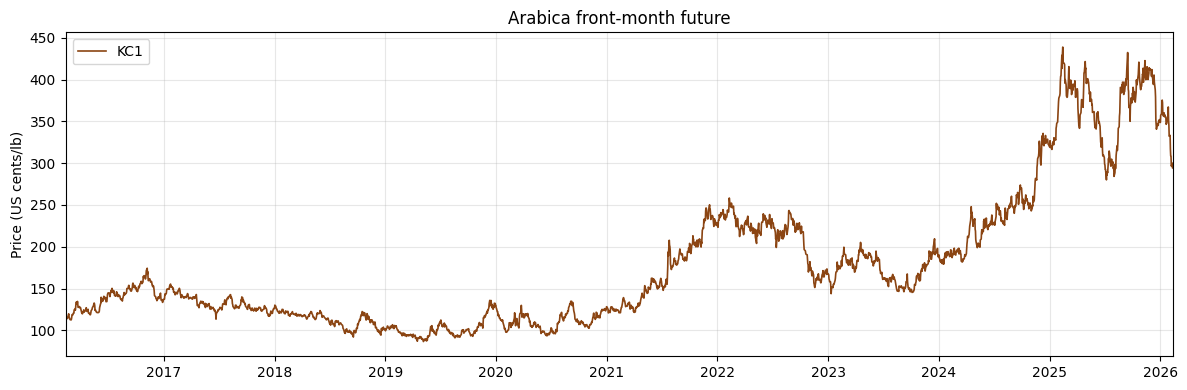

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prices.index, prices[ANCHOR], color="saddlebrown", lw=1.2, label=ANCHOR)
ax.set_ylabel("Price (US cents/lb)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
ax.set_xlim([pd.to_datetime('2016-02-12'), pd.to_datetime('2026-02-12')])
ax.set_title("Arabica front-month future")
plt.tight_layout()
plt.show()

## 2. Log-prices and in-sample / out-of-sample split

In-sample : 2016-02-12 -> 2023-02-13 (1826 obs)
Out-sample: 2023-02-13 -> 2026-02-12 (784 obs)


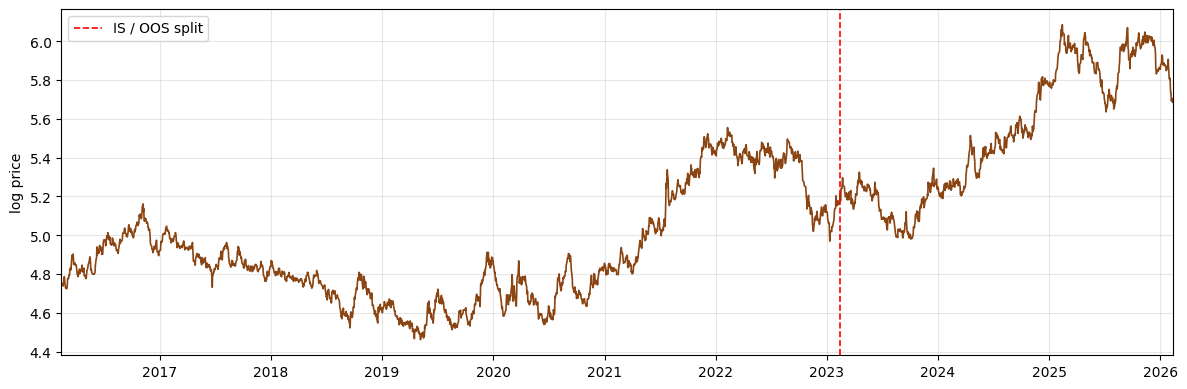

In [10]:
log_prices = data.to_log_prices(prices)
log_is, log_oos, split_date = data.train_test_split(
    log_prices, ANCHOR, cfg["split"]["ratio"]
)
print(f"In-sample : {log_is.index[0].date()} -> {split_date.date()} ({len(log_is)} obs)")
print(f"Out-sample: {split_date.date()} -> {log_oos.index[-1].date()} ({len(log_oos)} obs)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(log_prices[ANCHOR], color="saddlebrown", lw=1.2)
ax.axvline(split_date, color="red", ls="--", lw=1.2, label="IS / OOS split")
ax.set_ylabel("log price"); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim([pd.to_datetime('2016-02-12'), pd.to_datetime('2026-02-12')])
plt.tight_layout()
plt.show()

All screening and calibration below uses the **in-sample window only**.
The out-of-sample window stays untouched until the backtest in notebook 02.

## 3. ADF unit-root screening

In [11]:
exclude = set(cfg["universe"]["exclude"]) | {ANCHOR}
adf_results = stat_tests.adf_screen(log_is, exclude=exclude)
adf_results.round(4)

,asset,n_obs,adf_stat,p_value
0,QSR,1826,-3.4747,0.0087
1,SJM,1826,-2.0174,0.2790
2,KDP,1826,-1.7826,0.3891
3,JVA,1826,-1.7309,0.4153
4,KO,1826,-1.5459,0.5107
5,NSGRY,1826,-1.4390,0.5635
6,MCD,1826,-1.3929,0.5857
7,NESN,1826,-1.3205,0.6198
8,MDLZ,1826,-1.2068,0.6707
9,SBUX,1826,-1.0265,0.7435


High p-values fail to reject the unit root: the series are $I(1)$, as required.
A *stationary* price series would already be mean-reverting on its own and
admit no long-run equilibrium relationship to trade.

## 4. Engle-Granger cointegration against KC1

In [12]:
eg_results = stat_tests.engle_granger_screen(log_is, ANCHOR, exclude=exclude)
display(eg_results.round(4))

summary = stat_tests.summary_table(log_is, ANCHOR, adf_results, eg_results)
summary.round(4)

,asset,n_obs,beta,alpha,r_squared,p_value,cointegrated
0,SJM,1826,1.5513,-2.5471,0.4228,0.0442,True
1,KO,1826,1.1565,0.3843,0.3053,0.2213,False
2,MDLZ,1826,0.8565,1.5390,0.2788,0.2380,False
3,JVA,1826,-0.2410,5.2441,0.0525,0.3607,False
4,FARM,1826,-0.1549,5.3188,0.1804,0.3721,False
5,NSGRY,1826,0.5706,2.2910,0.1749,0.4137,False
6,NESN,1826,0.6173,2.1002,0.1618,0.4167,False
7,MCD,1826,0.4049,2.7903,0.1424,0.4360,False
8,SBUX,1826,0.3476,3.4063,0.1133,0.4461,False
9,QSR,1826,-0.2304,5.8383,0.0176,0.4584,False


,n_obs,mean,std,skew,kurtosis,corr_with_target,adf_p_value,eg_p_value
SJM,1826,4.8040,0.1134,0.1501,-0.7060,0.6502,0.2790,0.0442
KO,1826,3.9094,0.1292,0.4254,-0.9648,0.5525,0.5107,0.2213
MDLZ,1826,3.9303,0.1667,0.1029,-1.4428,0.5280,0.6707,0.2380
JVA,1826,1.4054,0.2572,-0.7746,0.2793,-0.2291,0.4153,0.3607
FARM,1826,2.6682,0.7414,-0.2524,-1.5275,-0.4247,0.9173,0.3721
NSGRY,1826,4.5820,0.1983,-0.0902,-1.4257,0.4182,0.5635,0.4137
NESN,1826,4.5442,0.1762,-0.1654,-1.4273,0.4022,0.6198,0.4167
MCD,1826,5.2235,0.2521,-0.3751,-0.9213,0.3774,0.5857,0.4360
SBUX,1826,4.3128,0.2619,0.2185,-1.3358,0.3366,0.7435,0.4461
QSR,1826,4.0493,0.1557,-1.1256,1.4315,-0.1326,0.0087,0.4584


Only `SJM` is cointegrated with `KC1` at the 5% level in the Bloomberg
sample; the other candidates show weak evidence ($p$-values 0.22–0.53). The
strategy therefore relies on the **multivariate basket** — the optimizer
searches for a synthetic combination that mean-reverts better than any
individual pair. This weak cointegration foundation is the key structural
limitation discussed in the report.

## 5. Visual check of the selected basket

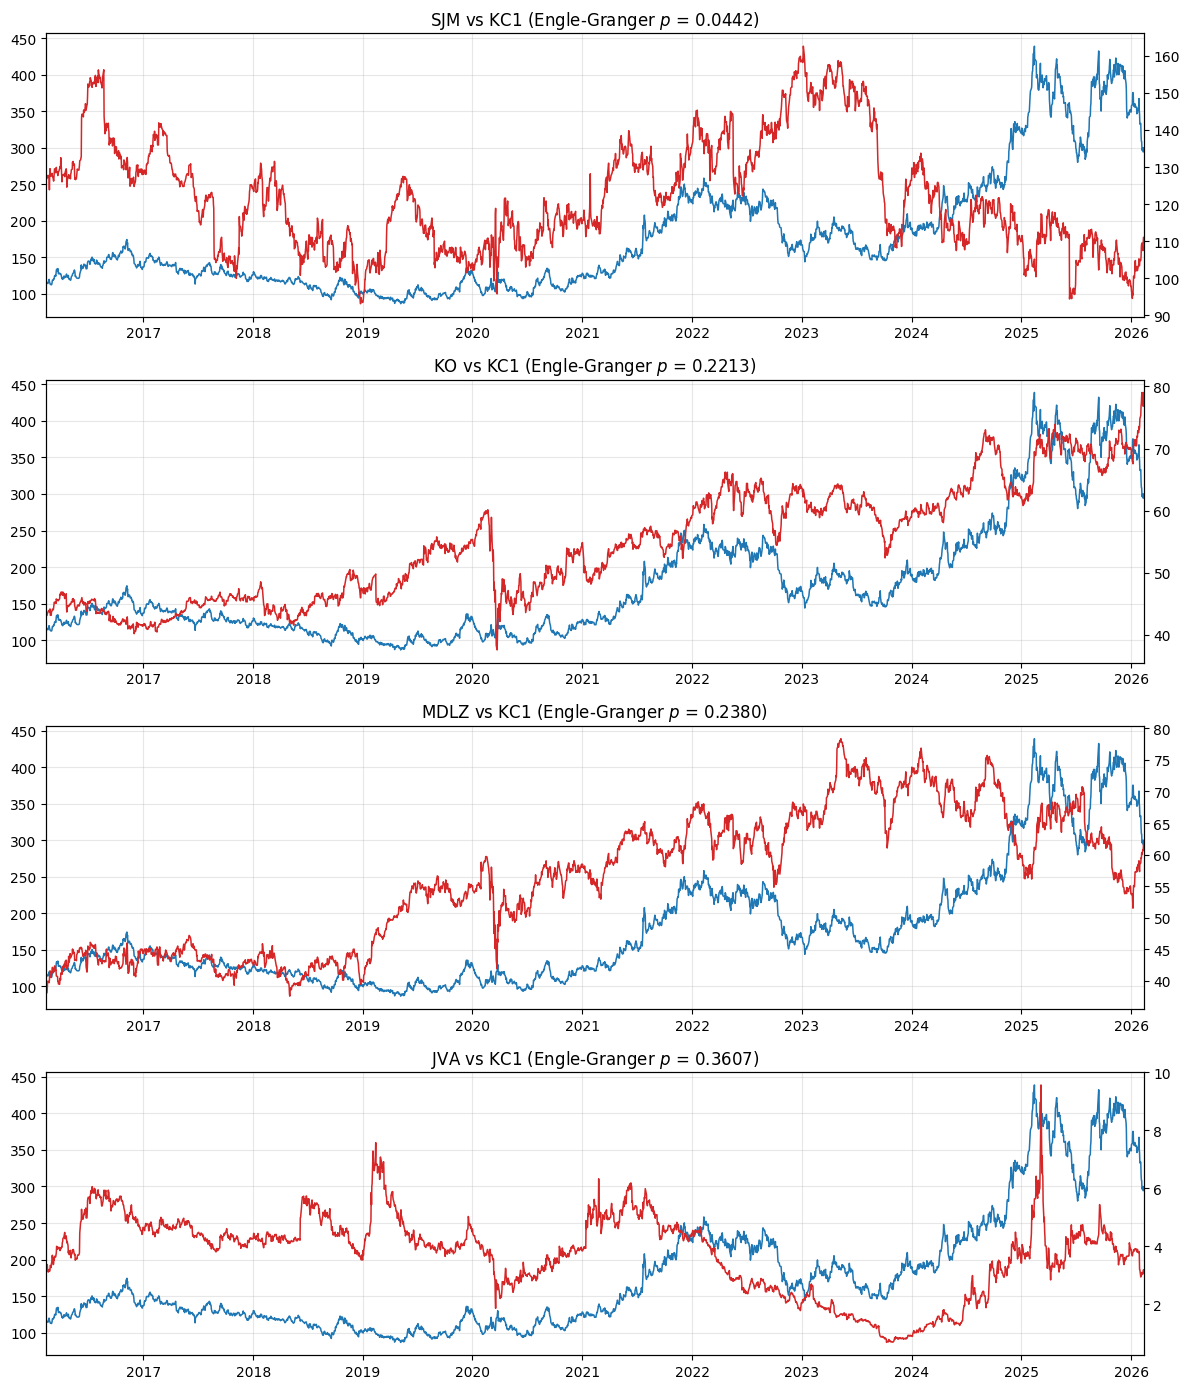

In [15]:
top4 = eg_results.head(4)["asset"].tolist()
fig, axes = plt.subplots(len(top4), 1, figsize=(12, 3.5 * len(top4)))
for ax, asset in zip(np.atleast_1d(axes), top4):
    pair = pd.concat([prices[ANCHOR], prices[asset]], axis=1).dropna()
    ax2 = ax.twinx()
    ax.plot(pair.index, pair[ANCHOR], color="tab:blue", lw=1.1, label=ANCHOR)
    ax2.plot(pair.index, pair[asset], color="tab:red", lw=1.1, label=asset)
    pval = eg_results.loc[eg_results["asset"] == asset, "p_value"].iloc[0]
    ax.set_title(f"{asset} vs {ANCHOR} (Engle-Granger $p$ = {pval:.4f})")
    ax.grid(alpha=0.3)
    ax.set_xlim([pd.to_datetime('2016-02-12'), pd.to_datetime('2026-02-12')])
plt.tight_layout(); plt.show()